In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score
import joblib


In [154]:
df = pd.read_csv("/content/fraud.csv", na_values=['', 'nan', 'NAN'])
df.head()

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


In [155]:
df['age'].unique()

array(["'4'", "'2'", "'3'", "'5'", "'1'", "'6'", "'U'", "'0'"],
      dtype=object)

In [156]:
df.columns = [c.strip().lower() for c in df.columns]

In [157]:
df['age'] = (df['age'].astype(str).str.replace("'", "", regex=False).str.replace('"', "", regex=False).str.strip().str.upper())
df['gender'] = (df['gender'].astype(str).str.replace("'", "", regex=False).str.replace('"', "", regex=False).str.strip().str.upper())

In [158]:
df = df.dropna(subset=['age', 'gender']).reset_index(drop=True)

In [159]:
df['step'] = pd.to_numeric(df['step'], errors='coerce')
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df['fraud'] = pd.to_numeric(df['fraud'], errors='coerce').astype(int)

In [160]:
df['age'].unique()

array(['4', '2', '3', '5', '1', '6', 'U', '0'], dtype=object)

In [161]:
df['gender'].unique()

array(['M', 'F', 'E', 'U'], dtype=object)

In [162]:
df.isnull().sum()

,0
step,0
customer,0
age,0
gender,0
zipcodeori,0
merchant,0
zipmerchant,0
category,0
amount,0
fraud,0


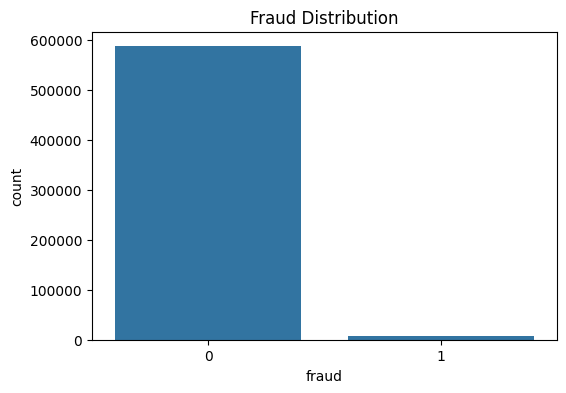

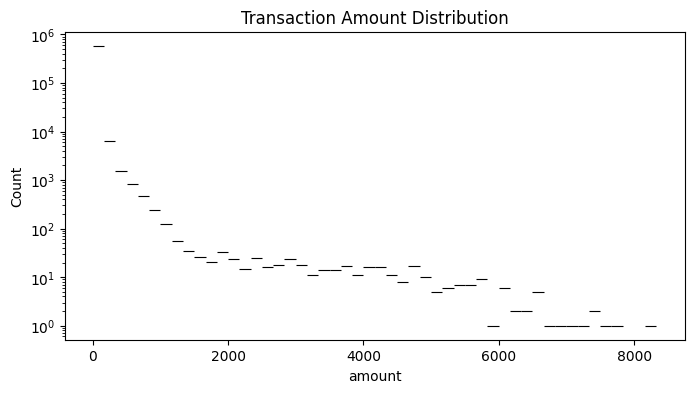

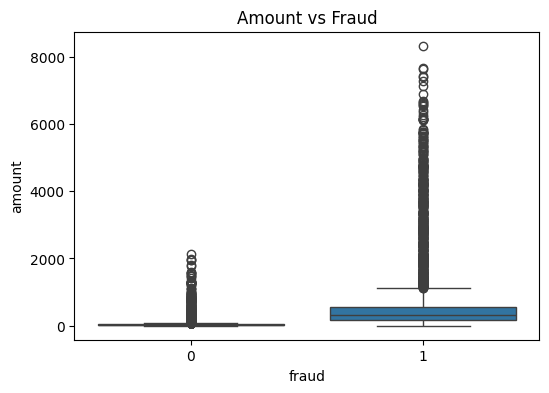

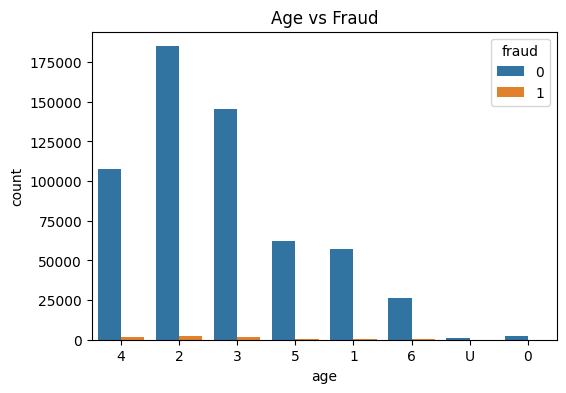

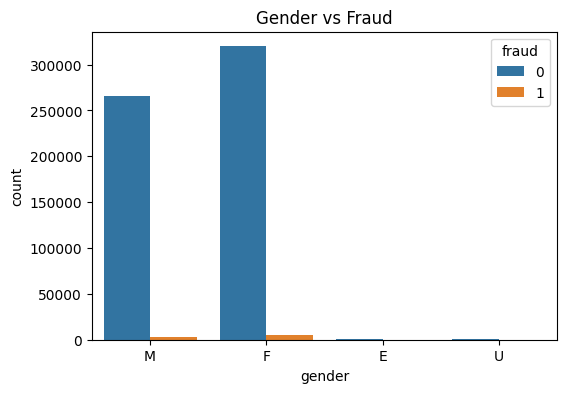

In [163]:
plt.figure(figsize=(6,4))
sns.countplot(x='fraud', data=df)
plt.title('Fraud Distribution')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df['amount'], bins=50, log_scale=(False, True))
plt.title('Transaction Amount Distribution')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='fraud', y='amount', data=df)
plt.title('Amount vs Fraud')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='age', hue='fraud', data=df)
plt.title('Age vs Fraud')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='fraud', data=df)
plt.title('Gender vs Fraud')
plt.show()


In [164]:
df['hour'] = df['step'] % 24

In [165]:
df['age'] = df['age'].fillna('U')
df['gender'] = df['gender'].fillna('U')

df = pd.get_dummies(df, columns=['age', 'gender'], drop_first=True)

In [166]:
X = df.drop(columns=['fraud', 'customer', 'merchant', 'zipcodeori', 'zipmerchant'], errors='ignore')
y = df['fraud']

In [167]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [168]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)


In [169]:
num_cols = [c for c in ['amount', 'hour'] if c in X_train.columns]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [170]:
use_smote = False
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    use_smote = True
except:
    X_res, y_res = X_train, y_train


In [171]:
combined = pd.concat([X_res, X_test], axis=0, ignore_index=True)
combined = combined.applymap(lambda x: str(x).replace("'", "").replace('"', "").strip() if isinstance(x, str) else x)
combined = pd.get_dummies(combined, drop_first=True)

X_res = combined.iloc[:len(X_res)].reset_index(drop=True)
X_test = combined.iloc[len(X_res):].reset_index(drop=True)

X_res = X_res.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)


/tmp/ipython-input-2646204954.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined = combined.applymap(lambda x: str(x).replace("'", "").replace('"', "").strip() if isinstance(x, str) else x)


In [172]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_res, y_res)


GradientBoostingClassifier(random_state=42)

In [173]:
preds = gb.predict(X_test)
probs = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting Results:")
print(classification_report(y_test, preds, digits=4))
print("ROC AUC:", round(roc_auc_score(y_test, probs), 4))


Gradient Boosting Results:
              precision    recall  f1-score   support

           0     0.9958    0.9986    0.9972    117489
           1     0.8555    0.6535    0.7409      1440

    accuracy                         0.9945    118929
   macro avg     0.9256    0.8261    0.8691    118929
weighted avg     0.9941    0.9945    0.9941    118929

ROC AUC: 0.9928


In [ ]:
joblib.dump(best_model, 'fraud_model.pkl')